# ISIC 2024 - Blending LightGBM and the CNN

LightGBM (metadata) and the CNN (images) were good on different folds, so they probably make different mistakes,
which is when combining them should help.

1. Load both out-of-fold predictions
2. Check that the scores match the ones from the other notebooks
3. Turn the predictions into ranks
4. How similar are the two models?
5. Blend with weight `w` from 0 to 1
6. Compare and save

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

sys.path.insert(0, '../src')
from isic_pauc import p_auc_tpr

DATA_DIR = '../data'
N_FOLDS = 5

## 1. Load the out-of-fold predictions

In [2]:
oof_lgbm = pd.read_csv(f'{DATA_DIR}/oof_lgbm.csv')
oof_cnn = pd.read_csv(f'{DATA_DIR}/oof_cnn.csv')

oof_lgbm = oof_lgbm.rename(columns={'oof': 'lgbm'})
oof_cnn = oof_cnn[['isic_id', 'oof_cnn']].rename(columns={'oof_cnn': 'cnn'})

df = oof_lgbm.merge(oof_cnn, on='isic_id', how='inner')

assert len(df) == 401059
df.head()

,isic_id,patient_id,target,fold,lgbm,cnn
0,ISIC_0015670,IP_1235828,0,1,0.000024,0.011834
1,ISIC_0015845,IP_8170065,0,4,0.999918,0.005450
2,ISIC_0015864,IP_6724798,0,4,0.000009,0.006334
3,ISIC_0015902,IP_4111386,0,1,0.000037,0.005295
4,ISIC_0024200,IP_8313778,0,1,0.000128,0.002395


## 2. Sanity check
Each model alone should give the same pAUC as in `03_lightgbm` and `04_cnn`.

In [3]:
def score_per_fold(df, col):
    paucs, aucs = [], []
    for fold in range(N_FOLDS):
        val = df[df['fold'] == fold]
        paucs.append(p_auc_tpr(val['target'], val[col], min_tpr=0.80))
        aucs.append(roc_auc_score(val['target'], val[col]))
    return paucs, aucs

for col in ['lgbm', 'cnn']:
    paucs, aucs = score_per_fold(df, col)
    print(f'{col:5s} pAUC: {np.mean(paucs):.4f} +/- {np.std(paucs):.4f}   AUC: {np.mean(aucs):.4f}')

lgbm  pAUC: 0.1644 +/- 0.0079   AUC: 0.9545


cnn   pAUC: 0.1432 +/- 0.0134   AUC: 0.9209


## 3. Ranks instead of probabilities
The LightGBM probabilities are too high because of the downsampling and the CNN's are on a different scale, so
averaging the raw numbers would give one model more weight than intended. Ranks put both on the same 0-1 scale,
and the pAUC only depends on the order anyway. I rank within each fold because every fold was predicted by a
different model.

In [4]:
df['lgbm_rank'] = df.groupby('fold')['lgbm'].rank(pct=True)
df['cnn_rank'] = df.groupby('fold')['cnn'].rank(pct=True)

df[['lgbm', 'lgbm_rank', 'cnn', 'cnn_rank']].describe()

,lgbm,lgbm_rank,cnn,cnn_rank
count,4.010590e+05,401059.000000,401059.000000,401059.000000
mean,1.796572e-02,0.500006,0.036523,0.500006
std,1.053823e-01,0.288675,0.101689,0.288675
min,1.889309e-07,0.000012,0.000004,0.000012
25%,7.075354e-06,0.250005,0.003028,0.250005
50%,2.985365e-05,0.500006,0.006570,0.500006
75%,2.397423e-04,0.750008,0.018976,0.750008
max,9.999804e-01,1.000000,0.999586,1.000000


## 4. How similar are the two models?
If the two rankings were almost the same, blending couldn't help much. The interesting part is the malignant
lesions: does the CNN rank some cancers high that LightGBM missed?

In [5]:
corr_all = df['lgbm_rank'].corr(df['cnn_rank'])

corr_malignant = df.loc[df['target'] == 1, 'lgbm_rank'].corr(
    df.loc[df['target'] == 1, 'cnn_rank']
)

print(f'All lesions:       {corr_all:.4f}')
print(f'Malignant lesions: {corr_malignant:.4f}')

All lesions:       0.4628
Malignant lesions: 0.3941


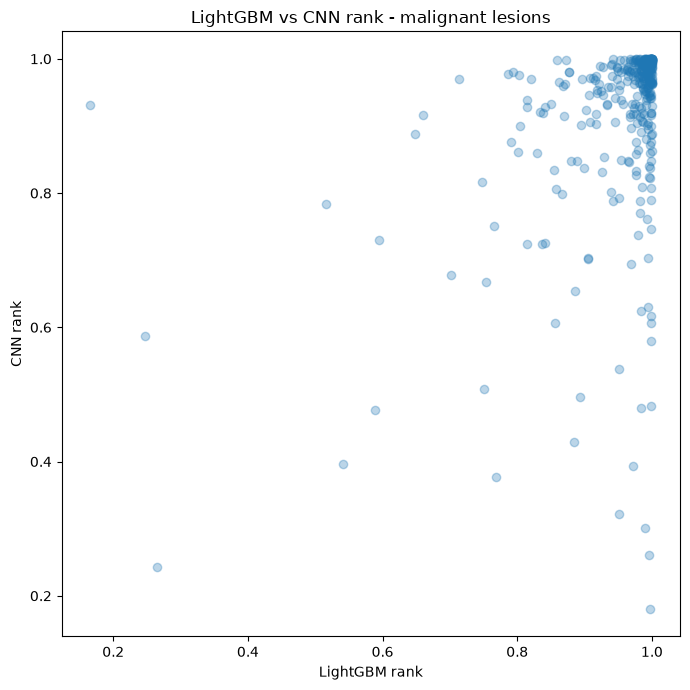

In [6]:
malignant = df[df['target'] == 1]

plt.figure(figsize=(7, 7))
plt.scatter(malignant['lgbm_rank'], malignant['cnn_rank'], alpha=0.3)
plt.xlabel('LightGBM rank')
plt.ylabel('CNN rank')
plt.title('LightGBM vs CNN rank - malignant lesions')
plt.tight_layout()
plt.show()

## 5. Blend with weight w
`blend = w * lgbm_rank + (1 - w) * cnn_rank`, where `w = 1` is LightGBM alone and `w = 0` is the CNN alone.

Choosing `w` on the same out-of-fold predictions I evaluate on is a small form of tuning on the validation data,
so the best score is a little optimistic. With only one number tuned the effect should be small.

In [7]:
results = []

for w in np.linspace(0, 1, 11):
    # Blend the rank predictions
    df['blend'] = w * df['lgbm_rank'] + (1 - w) * df['cnn_rank']

    # Score the blend per fold
    paucs, aucs = score_per_fold(df, 'blend')

    results.append({
        'w': round(w, 1),
        'pauc_mean': np.mean(paucs),
        'pauc_std': np.std(paucs),
        'auc_mean': np.mean(aucs),
        **{f'fold {i}': p for i, p in enumerate(paucs)}
    })

results = pd.DataFrame(results)
results.round(4)

,w,pauc_mean,pauc_std,auc_mean,fold 0,fold 1,fold 2,fold 3,fold 4
0,0.0,0.1432,0.0134,0.9209,0.1496,0.1586,0.1516,0.1350,0.1212
1,0.1,0.1491,0.0123,0.9322,0.1552,0.1622,0.1575,0.1424,0.1284
2,0.2,0.1547,0.0107,0.9402,0.1601,0.1649,0.1628,0.1499,0.1358
3,0.3,0.1597,0.0091,0.9466,0.1645,0.1665,0.1674,0.1570,0.1430
4,0.4,0.1636,0.0079,0.9515,0.1685,0.1671,0.1708,0.1630,0.1486
5,0.5,0.1665,0.0072,0.9552,0.1715,0.1666,0.1734,0.1678,0.1530
6,0.6,0.1683,0.0068,0.9577,0.1736,0.1653,0.1748,0.1713,0.1565
7,0.7,0.1691,0.0067,0.9591,0.1744,0.1633,0.1752,0.1738,0.1588
8,0.8,0.1689,0.0071,0.9595,0.1741,0.1608,0.1746,0.1753,0.1596
9,0.9,0.1675,0.0077,0.9585,0.1727,0.1575,0.1726,0.1756,0.1588


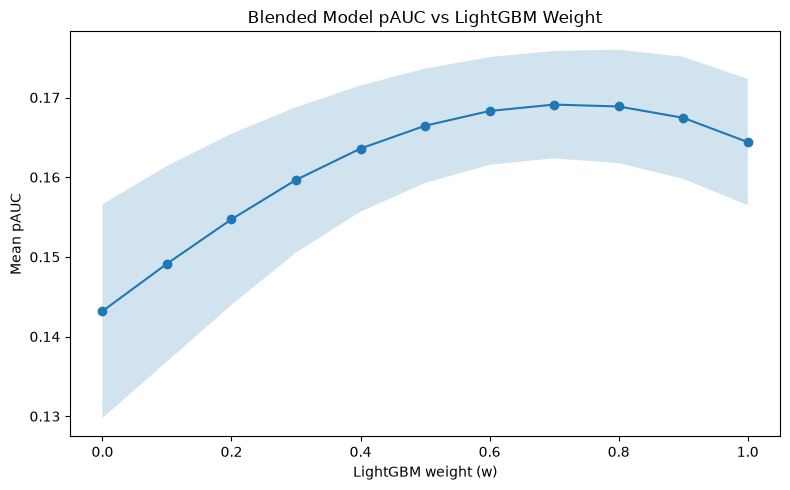

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(results['w'], results['pauc_mean'], marker='o')
plt.fill_between(
    results['w'],
    results['pauc_mean'] - results['pauc_std'],
    results['pauc_mean'] + results['pauc_std'],
    alpha=0.2
)

plt.xlabel('LightGBM weight (w)')
plt.ylabel('Mean pAUC')
plt.title('Blended Model pAUC vs LightGBM Weight')
plt.tight_layout()
plt.show()

## 6. Compare and save

In [9]:
# Pick the w with the highest mean pAUC
best_w = results.loc[results['pauc_mean'].idxmax(), 'w']

df['blend'] = best_w * df['lgbm_rank'] + (1 - best_w) * df['cnn_rank']

# Get per-fold scores
lgbm_paucs, _ = score_per_fold(df, 'lgbm_rank')
cnn_paucs, _ = score_per_fold(df, 'cnn_rank')
blend_paucs, _ = score_per_fold(df, 'blend')

# Build comparison table
pauc_table = pd.DataFrame({
    'lgbm': lgbm_paucs,
    'cnn': cnn_paucs,
    'blend': blend_paucs
}, index=[f'fold {i}' for i in range(N_FOLDS)])

# Add mean and std rows
pauc_table.loc['mean'] = pauc_table.iloc[:N_FOLDS].mean()
pauc_table.loc['std'] = pauc_table.iloc[:N_FOLDS].std(ddof=0)

print(f'Best w: {best_w}')
pauc_table.round(4)

Best w: 0.7


,lgbm,cnn,blend
fold 0,0.1688,0.1496,0.1744
fold 1,0.1529,0.1586,0.1633
fold 2,0.1689,0.1516,0.1752
fold 3,0.1741,0.1350,0.1738
fold 4,0.1573,0.1212,0.1588
mean,0.1644,0.1432,0.1691
std,0.0079,0.0134,0.0067


- The rank correlation between the two models is only 0.46 (0.39 for the malignant lesions), so they really do rank the lesions differently, which is why blending helps.
- The best blend (w = 0.7, so 70% LightGBM and 30% CNN) reaches a pAUC of 0.1691 +/- 0.0067. That is +0.0047 over LightGBM alone and better on 4 of 5 folds (fold 3 is a tie, 0.1738 vs 0.1741). The std is also the lowest so far.
- The gain is a bit smaller than one std, so it's a consistent improvement rather than a big one. The biggest gain is on fold 1 (+0.010), the fold where the CNN was better than LightGBM.
- The curve is flat between w = 0.6 and 0.8 (0.1683 to 0.1691), so the exact weight doesn't matter much and picking w on the out-of-fold predictions shouldn't make the result much too optimistic.

In [10]:
oof_blend = df[
    ['isic_id', 'patient_id', 'target', 'fold',
     'lgbm_rank', 'cnn_rank', 'blend']
]

oof_blend.to_csv('../data/oof_blend.csv', index=False)
pd.read_csv('../data/oof_blend.csv').head()

,isic_id,patient_id,target,fold,lgbm_rank,cnn_rank,blend
0,ISIC_0015670,IP_1235828,0,1,0.518682,0.721734,0.579598
1,ISIC_0015845,IP_8170065,0,4,0.999938,0.228313,0.768450
2,ISIC_0015864,IP_6724798,0,4,0.326381,0.291398,0.315886
3,ISIC_0015902,IP_4111386,0,1,0.576081,0.595704,0.581968
4,ISIC_0024200,IP_8313778,0,1,0.713381,0.433033,0.629277
